<a href="https://colab.research.google.com/github/14marcos1/ELT574_51687_ATIVIDADE_1_/blob/main/mapa_de_minas_distancias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install geopandas geobr matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.2 MB/s eta 0:00:00
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: lxml
    Found existing installation: lxml 6.0.2
    Uninstalling lxml-6.0.2:
      Successfully uninstalled lxml-6.0.2
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.3
    Uninstalling geopandas-1.1.3:
      Successfully uninstalled geopandas-1.1.3


Carregando mapa de Minas Gerais...


/tmp/ipykernel_155/2236674690.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mapa_cidades['coords'] = mapa_cidades['geometry'].centroid


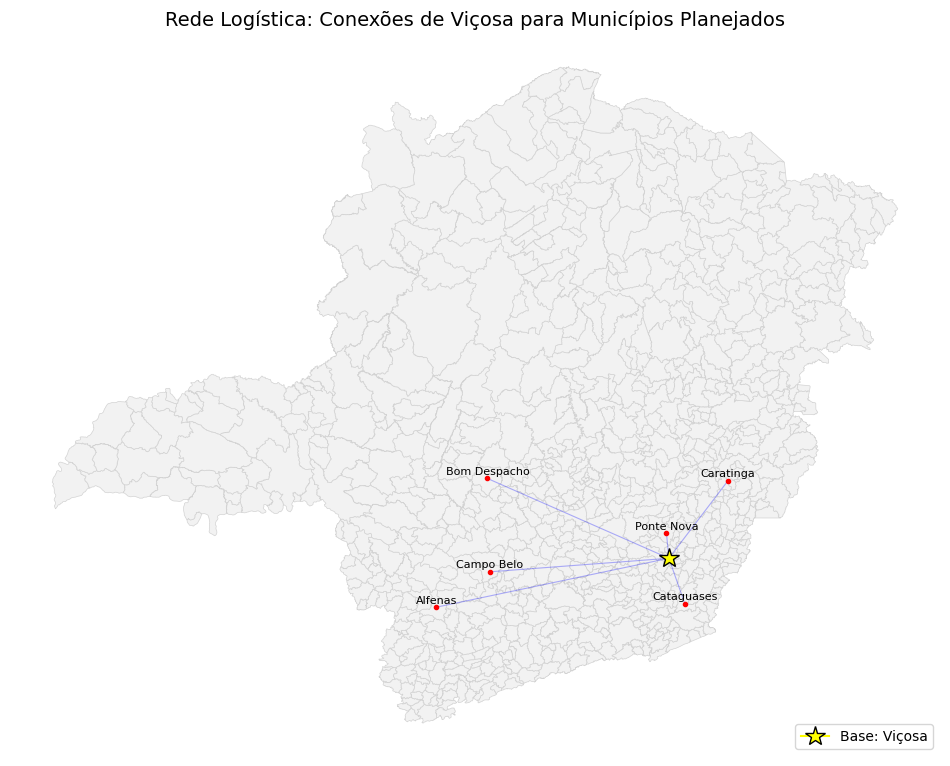

In [2]:
import geobr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# 1. Dados fornecidos (Amostra dos dados para o exemplo)
data = {
    'Município': ['Alfenas', 'Bom Despacho', 'Campo Belo', 'Caratinga', 'Cataguases', 'Ponte Nova', 'Viçosa'],
    'Distância': [327, 272, 249, 132, 73, 38, 0]
}
df_distancias = pd.DataFrame(data)

# 2. Baixar mapas de MG (Municípios)
print("Carregando mapa de Minas Gerais...")
mg_municipios = geobr.read_municipality(code_muni="MG", year=2020)

# 3. Obter coordenadas (Centroides) dos municípios da sua lista
# Precisamos filtrar o GeoDataFrame para pegar apenas os que estão na sua tabela
cidades_alvo = df_distancias['Município'].tolist()
mapa_cidades = mg_municipios[mg_municipios['name_muni'].isin(cidades_alvo)].copy()

# Criar pontos (Lat/Long) para o centro de cada cidade
mapa_cidades['coords'] = mapa_cidades['geometry'].centroid
points = dict(zip(mapa_cidades['name_muni'], mapa_cidades['coords']))

# Coordenada da Base (Viçosa)
vicosa_point = points.get('Viçosa')

# 4. Configuração do Gráfico
fig, ax = plt.subplots(figsize=(12, 10))

# Desenhar o fundo (todos os municípios de MG)
mg_municipios.plot(ax=ax, color='#f2f2f2', edgecolor='#d3d3d3', linewidth=0.5)

# 5. Desenhar as linhas de conexão (Rotas de Planejamento)
for cidade, point in points.items():
    if cidade != 'Viçosa':
        # Criar linha entre Viçosa e a cidade
        line = LineString([vicosa_point, point])
        gpd.GeoSeries([line]).plot(ax=ax, color='blue', alpha=0.3, linewidth=0.8)

        # Marcar o ponto da cidade destino
        ax.plot(point.x, point.y, 'ro', markersize=3)
        # Adicionar nome da cidade
        ax.text(point.x, point.y + 0.05, cidade, fontsize=8, ha='center')

# 6. Destacar a Base (Viçosa) com uma estrela
ax.plot(vicosa_point.x, vicosa_point.y, marker='*', color='yellow',
        markersize=15, markeredgecolor='black', label='Base: Viçosa')

# Estilização final
ax.set_title("Rede Logística: Conexões de Viçosa para Municípios Planejados", fontsize=14)
ax.axis('off') # Remove os eixos de latitude/longitude
plt.legend(loc='lower right')

plt.show()

Baixando malha municipal de MG...


/tmp/ipykernel_155/1944052288.py:35: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mapa_cidades['coords'] = mapa_cidades['geometry'].centroid


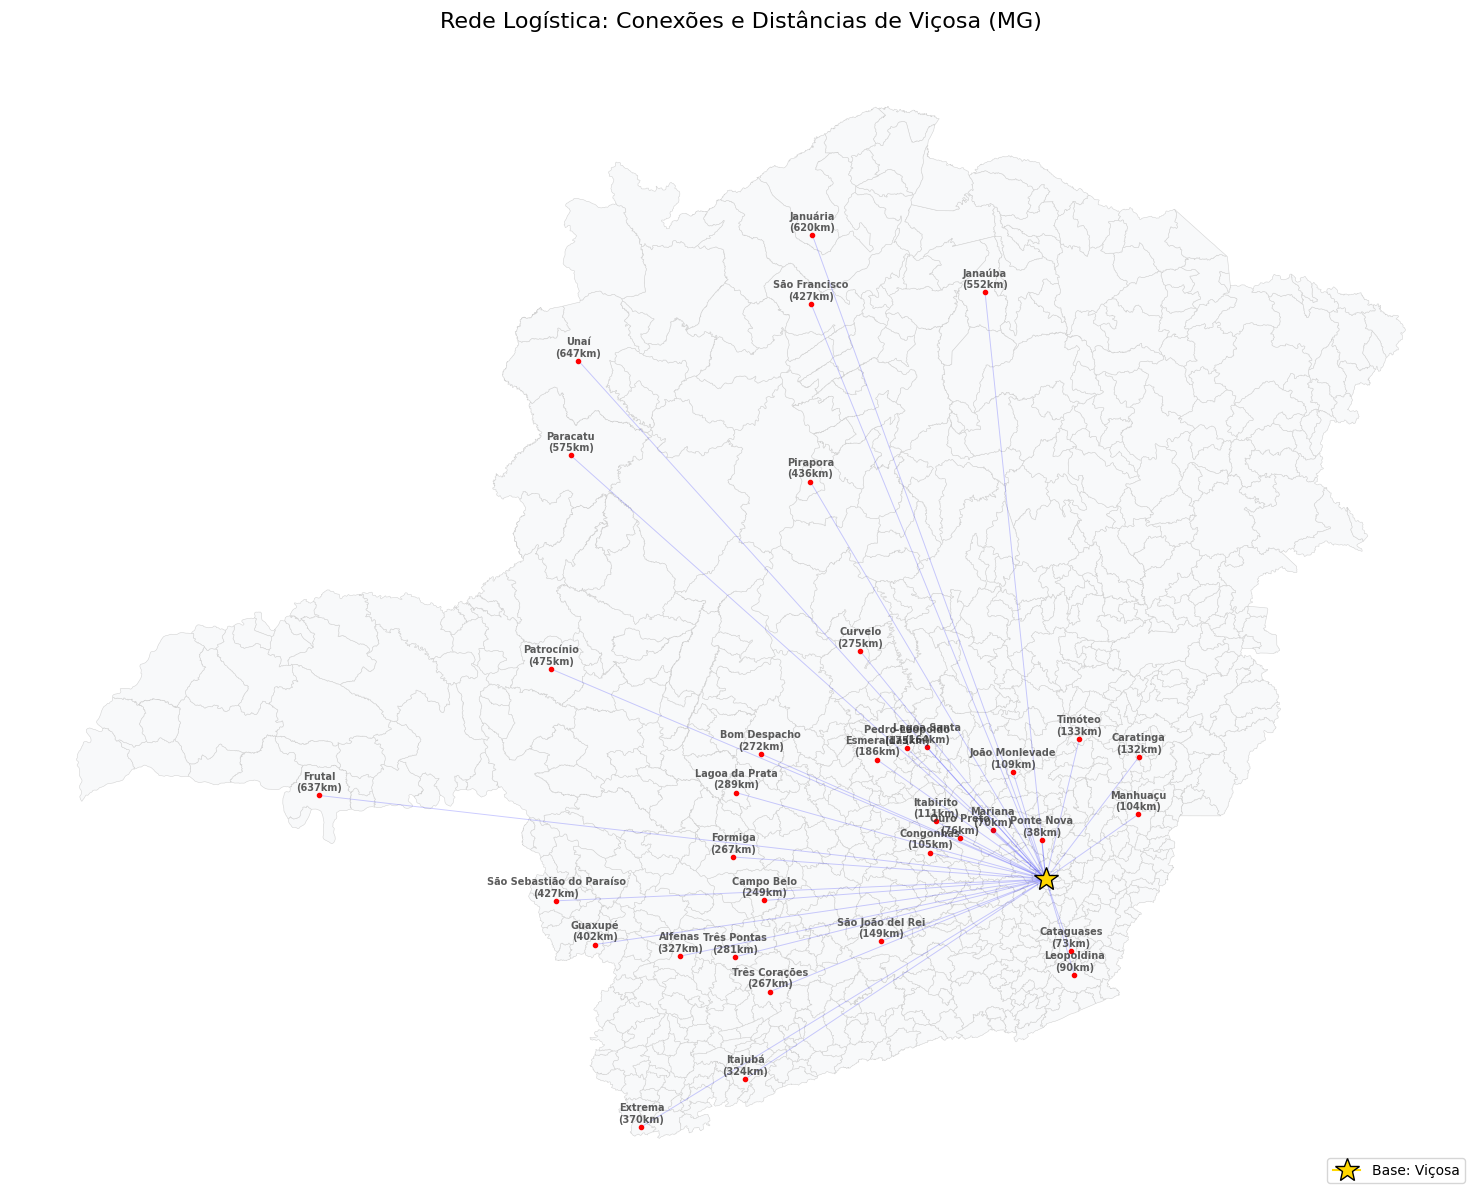

In [3]:
import geobr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# 1. Dados completos (36 municípios e distâncias fornecidas)
dados = [
    ["Alfenas", 327], ["Bom Despacho", 272], ["Campo Belo", 249], ["Caratinga", 132],
    ["Cataguases", 73], ["Congonhas", 105], ["Curvelo", 275], ["Esmeraldas", 186],
    ["Extrema", 370], ["Formiga", 267], ["Frutal", 637], ["Guaxupé", 402],
    ["Itabirito", 111], ["Itajubá", 324], ["Janaúba", 552], ["Januária", 620],
    ["João Monlevade", 109], ["Lagoa da Prata", 289], ["Lagoa Santa", 164],
    ["Leopoldina", 90], ["Manhuaçu", 104], ["Mariana", 70], ["Ouro Preto", 76],
    ["Paracatu", 575], ["Patrocínio", 475], ["Pedro Leopoldo", 175], ["Pirapora", 436],
    ["Ponte Nova", 38], ["São Francisco", 427], ["São João del Rei", 149],
    ["São Sebastião do Paraíso", 427], ["Timóteo", 133], ["Três Corações", 267],
    ["Três Pontas", 281], ["Unaí", 647], ["Viçosa", 0]
]

df_dist = pd.DataFrame(dados, columns=["Municipio", "Distancia"])

# 2. Carregar mapa de Minas Gerais e filtrar cidades
print("Baixando malha municipal de MG...")
mg_map = geobr.read_municipality(code_muni="MG", year=2020)

# Normalização de nomes para garantir o match (ignorar maiúsculas/minúsculas)
mg_map['name_muni_norm'] = mg_map['name_muni'].str.upper()
df_dist['muni_norm'] = df_dist['Municipio'].str.upper()

# Unir os dados da tabela com os dados geográficos
mapa_cidades = mg_map.merge(df_dist, left_on='name_muni_norm', right_on='muni_norm')

# 3. Calcular centros (centroides) para desenhar as linhas e textos
mapa_cidades['coords'] = mapa_cidades['geometry'].centroid
points = dict(zip(mapa_cidades['Municipio'], mapa_cidades['coords']))
dist_dict = dict(zip(mapa_cidades['Municipio'], mapa_cidades['Distancia']))

# Coordenada de Viçosa (nossa base)
vicosa_pt = points.get('Viçosa')

# 4. Configuração visual do mapa
fig, ax = plt.subplots(figsize=(15, 12))

# Desenhar fundo cinza (Estado de MG)
mg_map.plot(ax=ax, color='#f8f9fa', edgecolor='#d3d3d3', linewidth=0.4)

# 5. Loop para desenhar as linhas (rotas) e distâncias
for cidade, pt in points.items():
    if cidade != 'Viçosa':
        # Desenhar linha de conexão
        rota = LineString([vicosa_pt, pt])
        gpd.GeoSeries([rota]).plot(ax=ax, color='blue', alpha=0.2, linewidth=0.7)

        # Marcar ponto vermelho na cidade destino
        ax.plot(pt.x, pt.y, 'ro', markersize=3)

        # Adicionar Nome + Distância (ex: Alfenas 327km)
        # O ajuste de +0.05 na latitude serve para o texto não ficar em cima do ponto
        label = f"{cidade}\n({dist_dict[cidade]}km)"
        ax.text(pt.x, pt.y + 0.04, label, fontsize=7, ha='center',
                color='#333', fontweight='bold', alpha=0.8)

# 6. Destacar a Base: Viçosa
ax.plot(vicosa_pt.x, vicosa_pt.y, marker='*', color='gold',
        markersize=18, markeredgecolor='black', label='Base: Viçosa', zorder=5)

# Título e Legenda
plt.title("Rede Logística: Conexões e Distâncias de Viçosa (MG)", fontsize=16, pad=20)
plt.legend(loc='lower right', frameon=True)
ax.axis('off')

# Salvar e mostrar
plt.tight_layout()
plt.savefig("mapa_logistico_vicosa.png", dpi=300)
plt.show()